In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Load saved predictive models and preprocessors
model1 = joblib.load("../models/iri_prediction_model.pkl")
kmeans_fwd = joblib.load("../models/fwd_kmeans_model.pkl")
scaler_fwd = joblib.load("../models/fwd_scaler.pkl")
le_pav = joblib.load("../models/fwd_le_pav.pkl")
le_lane = joblib.load("../models/fwd_le_lane.pkl")
health_mapping = joblib.load("../models/fwd_health_mapping.pkl")

print("All models and preprocessors loaded successfully!")

# Load Raw Data
iri = pd.read_excel("../data/MON_HSS_PROFILE_SECTION.xlsx")
trf1 = pd.read_excel("../data/TRF_TREND_1.xlsx")
trf2 = pd.read_excel("../data/TRF_TREND.xlsx")
fwd = pd.read_excel("../data/MON_DEFL_DROP_DATA.xlsx")
exp = pd.read_excel("../data/EXPERIMENT_SECTION.xlsx")
# --- NEW: Load Climate Data ---
clim = pd.read_excel("../data/CLM_VWS_TEMP_ANNUAL.xlsx")

print("All raw data loaded!")

All models and preprocessors loaded successfully!
All raw data loaded!


In [2]:
# --- MODEL 1 (IRI) DATA PREP ---
iri['YEAR'] = pd.to_datetime(iri['VISIT_DATE']).dt.year
iri_clean = iri.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])['MRI'].mean().reset_index()

trf_merged = pd.merge(
    trf1[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND']],
    trf2[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 'ANNUAL_ESAL_TREND']],
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='outer'
)

df1 = pd.merge(iri_clean, trf_merged, on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'], how='inner')

# Impute missing traffic data via forward-fill
df1 = df1.sort_values(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])
df1['ANNUAL_ESAL_TREND'] = df1.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].ffill()
df1['AADTT_ALL_TRUCKS_TREND'] = df1.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['AADTT_ALL_TRUCKS_TREND'].ffill()
df1['ANNUAL_TRUCK_VOLUME_TREND'] = df1.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_TRUCK_VOLUME_TREND'].ffill()
df1 = df1.dropna().reset_index(drop=True)

df1['CUMULATIVE_ESAL'] = df1.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].cumsum()

# --- NEW: MERGE CLIMATE DATA ---
clim['SHRP_ID'] = clim['SHRP_ID'].astype(str).str.zfill(4)
clim['STATE_CODE'] = clim['STATE_CODE'].astype(int)
clim['YEAR'] = clim['YEAR'].astype(int)

df1['SHRP_ID'] = df1['SHRP_ID'].astype(str).str.zfill(4)
df1['STATE_CODE'] = df1['STATE_CODE'].astype(int)
df1['YEAR'] = df1['YEAR'].astype(int)

df1 = pd.merge(df1, clim, on=['SHRP_ID', 'STATE_CODE', 'YEAR'], how='inner')
# -------------------------------

# Predict and Score (UPDATED WITH CLIMATE FEATURES)
features1 = ['MRI', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND', 
             'ANNUAL_ESAL_TREND', 'CUMULATIVE_ESAL', 'YEAR',
             'MEAN_ANN_TEMP_AVG', 'FREEZE_INDEX_YR', 'FREEZE_THAW_YR']
             
df1['CURRENT_ESTIMATED_IRI'] = df1['MRI']
df1['PREDICTED_FUTURE_IRI'] = model1.predict(df1[features1])

FAILURE_THRESHOLD = 2.5
df1['IRI_SCORE'] = (((FAILURE_THRESHOLD - df1['CURRENT_ESTIMATED_IRI']) / FAILURE_THRESHOLD) * 100).clip(0, 100)

# Aggregate to single score per section
df1_section = df1.groupby('SHRP_ID')['IRI_SCORE'].mean().reset_index()
print("Model 1 data ready. Unique sections:", df1_section['SHRP_ID'].nunique())

Model 1 data ready. Unique sections: 502


In [3]:
# --- MODEL 2 (FWD) DATA PREP ---
fwd['SHRP_ID'] = fwd['SHRP_ID'].astype(str).str.zfill(4)
exp_clean = exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'PAVEMENT_FAMILY']].drop_duplicates()

df2 = pd.merge(fwd, exp_clean, on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'], how='inner')
df2 = df2.dropna(subset=['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3', 'PEAK_DEFL_4', 'PEAK_DEFL_5', 'PEAK_DEFL_6', 'PEAK_DEFL_7', 'DROP_LOAD', 'DROP_HEIGHT', 'PAVEMENT_FAMILY', 'LANE_NO'])

# Encode
df2['PAVEMENT_FAMILY_ENC'] = le_pav.transform(df2['PAVEMENT_FAMILY'])
df2['LANE_NO_ENC'] = le_lane.transform(df2['LANE_NO'])

features2 = ['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3', 'PEAK_DEFL_4', 'PEAK_DEFL_5', 'PEAK_DEFL_6', 'PEAK_DEFL_7', 'DROP_LOAD', 'DROP_HEIGHT', 'PAVEMENT_FAMILY_ENC', 'LANE_NO_ENC']

# Standardize and Predict Clusters
X2_scaled = scaler_fwd.transform(df2[features2])
df2['CLUSTER'] = kmeans_fwd.predict(X2_scaled)

# Map to Health Category
df2['HEALTH'] = df2['CLUSTER'].map(health_mapping)

# Reverse mapping to find exact indices for Good and Poor clusters
reverse_mapping = {v: k for k, v in health_mapping.items()}
good_cluster_idx = reverse_mapping['Good']
poor_cluster_idx = reverse_mapping['Poor']

# Calculate EXACT continuous structural health score using cluster distances
distances = kmeans_fwd.transform(X2_scaled)
dist_to_good = distances[:, good_cluster_idx]
dist_to_poor = distances[:, poor_cluster_idx]

# Apply continuous formula: (Distance to Poor) / (Distance to Good + Distance to Poor) * 100
df2['FWD_SCORE'] = (dist_to_poor / (dist_to_good + dist_to_poor)) * 100

# Aggregate to single score per section
df2_section = df2.groupby('SHRP_ID')['FWD_SCORE'].mean().reset_index()
print("Model 2 data ready. Unique sections:", df2_section['SHRP_ID'].nunique())

Model 2 data ready. Unique sections: 5


In [ ]:
# Merge using LEFT JOIN to preserve all IRI sections
rhi_df = pd.merge(df1_section, df2_section, on='SHRP_ID', how='left')

# ==========================================
# 1. CALCULATE HISTORICAL RHI (Synchronized)
# ==========================================
rhi_df['HISTORICAL_RHI'] = np.where(
    rhi_df['FWD_SCORE'].isna(), 
    rhi_df['HISTORICAL_IRI_SCORE'],  # Fallback to 100% Surface if no FWD
    (rhi_df['HISTORICAL_IRI_SCORE'] * 0.40) + (rhi_df['FWD_SCORE'] * 0.60) # 40/60 Split
)

# ==========================================
# 2. CALCULATE CURRENT 2026 RHI (Fallback Only)
# ==========================================
# Because we do not have fresh 2026 FWD scans for old data, we MUST use 
# the Dynamic Fallback (100% Surface Score) to prevent chronological data leakage.
rhi_df['CURRENT_RHI'] = rhi_df['CURRENT_IRI_SCORE'] 

# Categorization logic
def classify_rhi(score):
    if score >= 75: return 'Good'
    elif score >= 50: return 'Fair'
    else: return 'Poor'

rhi_df['HISTORICAL_CONDITION'] = rhi_df['HISTORICAL_RHI'].apply(classify_rhi)
rhi_df['CURRENT_CONDITION'] = rhi_df['CURRENT_RHI'].apply(classify_rhi)

print("\nFinal Dual-RHI Sample:")
print(rhi_df[['SHRP_ID', 'HISTORICAL_RHI', 'HISTORICAL_CONDITION', 'CURRENT_RHI', 'CURRENT_CONDITION']].head(10))


Final RHI Breakdown:
ROAD_CONDITION
Poor    280
Fair    221
Good      1
Name: count, dtype: int64

Sample Data:
  SHRP_ID  IRI_SCORE  FWD_SCORE        RHI ROAD_CONDITION
0    0101  54.792519  52.213886  53.503202           Fair
1    0102  46.548061  52.918339  49.733200           Poor
2    0103  59.096260  62.039647  60.567953           Fair
3    0104  63.796482  63.570090  63.683286           Fair
4    0105  55.031738  61.161546  58.096642           Fair
5    0106  63.654442        NaN  63.654442           Fair
6    0107  61.989510        NaN  61.989510           Fair
7    0108  59.418472        NaN  59.418472           Fair
8    0109  66.639465        NaN  66.639465           Fair
9    0110  61.978813        NaN  61.978813           Fair


Saved final scores to CSV!


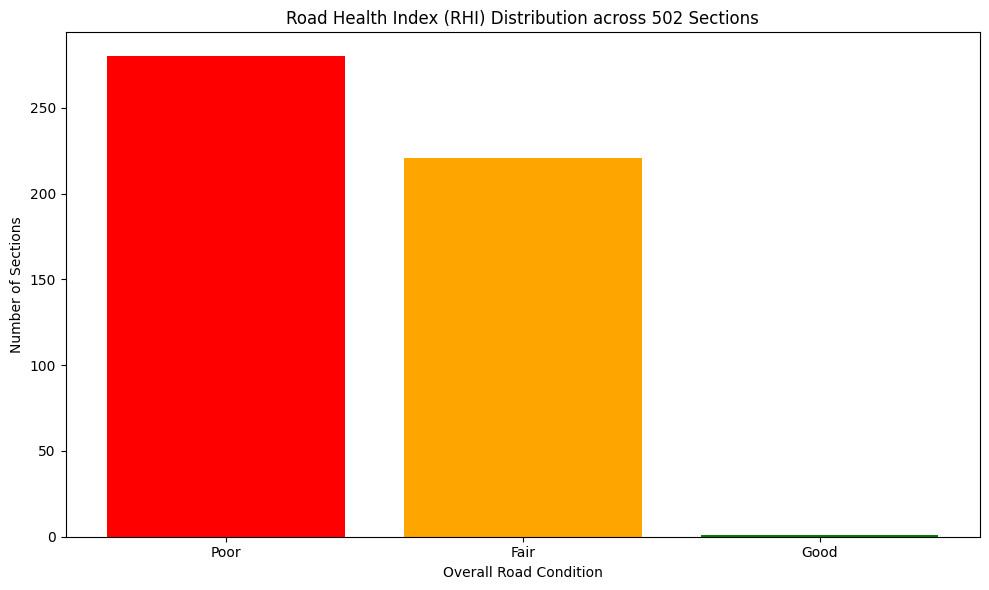

In [5]:
# Save to CSV
rhi_df.to_csv('../outputs/rhi_scores.csv', index=False)
print("Saved final scores to CSV!")

# Plot distribution
plt.figure(figsize=(10, 6))
condition_counts = rhi_df['ROAD_CONDITION'].value_counts()
colors = {'Good': 'green', 'Fair': 'orange', 'Poor': 'red'}

bars = plt.bar(condition_counts.index, condition_counts.values, color=[colors[c] for c in condition_counts.index])

plt.xlabel("Overall Road Condition")
plt.ylabel("Number of Sections")
plt.title(f"Road Health Index (RHI) Distribution across {len(rhi_df)} Sections")
plt.tight_layout()
plt.savefig('../outputs/rhi_distribution.png', dpi=150)
plt.show()